## Imports

In [ ]:
# Install additional depdendencies
%pip install -q lightning torchmetrics scikit-learn plotly ipywidgets pnpl

# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.3 MB/s eta 0:00:00


In [ ]:
from pnpl.datasets import LibriBrainPhoneme
from torch.utils.data import DataLoader
import pandas as pd
import random
import numpy as np
import torch
import platform

## Load one event file and explore phonemes

In [ ]:
train_dataset = LibriBrainPhoneme(
  data_path=f"{base_path}/data/",
  include_run_keys = [("0",1,"Sherlock1","1")],
  tmin=0.0,
  tmax = 0.5
)
f = f"{base_path}/data/Sherlock1/derivatives/events/sub-0_ses-1_task-Sherlock1_run-1_events.tsv"
data = pd.read_csv(f, sep='\t')
data

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(…)-0_ses-1_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock1/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/342M [00:00<?, ?B/s]

Done!
calculated stats for:  ('0', 1, 'Sherlock1', '1')


,idx,wavile,kind,segment,sentenceidx,wordidx,phonemeidx,timemeg,timeds,timechapter,timesentence,duration
0,1,segments/,silence,NaN,NaN,NaN,NaN,28.772,28.772,0.000,NaN,1.188
1,2,segments/,word,A,0.0,0.0,NaN,30.086,30.084,1.298,0.11,0.100
2,3,segments/,phoneme,ah_S,0.0,0.0,0.0,30.086,30.084,1.298,0.11,0.100
3,4,segments/,word,Study,0.0,1.0,NaN,30.186,30.184,1.398,0.21,0.370
4,5,segments/,phoneme,s_B,0.0,1.0,0.0,30.186,30.184,1.398,0.21,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...
12801,12802,segments/,phoneme,er_E,187.0,2.0,4.0,1098.278,1098.276,1064.404,0.79,0.060
12802,12803,segments/,word,one,187.0,3.0,NaN,1098.338,1098.336,1064.464,0.85,0.340
12803,12804,segments/,phoneme,w_B,187.0,3.0,0.0,1098.338,1098.336,1064.464,0.85,0.120
12804,12805,segments/,phoneme,ah_I,187.0,3.0,1.0,1098.458,1098.460,1064.584,0.97,0.100


In [ ]:
data[data["kind"]=="phoneme"].groupby(by="segment",as_index=False).count()

,segment,idx,wavile,kind,sentenceidx,wordidx,phonemeidx,timemeg,timeds,timechapter,timesentence,duration
0,aa_B,25,25,25,25,25,25,25,25,25,25,25
1,aa_E,2,2,2,2,2,2,2,2,2,2,2
2,aa_I,94,94,94,94,94,94,94,94,94,94,94
3,ae_B,113,113,113,113,113,113,113,113,113,113,113
4,ae_I,198,198,198,198,198,198,198,198,198,198,198
...,...,...,...,...,...,...,...,...,...,...,...,...
105,y_B,59,59,59,59,59,59,59,59,59,59,59
106,y_I,28,28,28,28,28,28,28,28,28,28,28
107,z_E,245,245,245,245,245,245,245,245,245,245,245
108,z_I,43,43,43,43,43,43,43,43,43,43,43


## Load all event data

In [ ]:
num_books = 7
num_chapters = [9, 12, 12, 12, 15, 14, 14]

In [ ]:
# Conditionally set num_workers to avoid multiprocessing issues (try increasing if performance is problematic)
num_workers = 2 if in_colab else 0

run_keys = [("0",str(i),f"Sherlock{j}","1") for j in range(1,8) for i in range(1, num_chapters[j-1])]
all_data = LibriBrainPhoneme(
  data_path=f"{base_path}/data/",
  include_run_keys = run_keys,
  tmin=0.0,
  tmax=0.5,
  preload_files = True
)

(…)-0_ses-8_task-Sherlock3_run-1_events.tsv: 0.00B [00:00, ?B/s]

(…)-0_ses-3_task-Sherlock7_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock7/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/669M [00:00<?, ?B/s]

Sherlock6/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/1.01G [00:00<?, ?B/s]

(…)0_ses-13_task-Sherlock6_run-1_events.tsv: 0.00B [00:00, ?B/s]

...

Sherlock3/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/1.05G [00:00<?, ?B/s]

Sherlock3/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/1.13G [00:00<?, ?B/s]

Sherlock5/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/330M [00:00<?, ?B/s]

(…)-0_ses-1_task-Sherlock6_run-1_events.tsv: 0.00B [00:00, ?B/s]

Done!
calculated stats for:  ('0', '2', 'Sherlock1', '1')
calculated stats for:  ('0', '3', 'Sherlock1', '1')
calculated stats for:  ('0', '4', 'Sherlock1', '1')
calculated stats for:  ('0', '5', 'Sherlock1', '1')
calculated stats for:  ('0', '6', 'Sherlock1', '1')
calculated stats for:  ('0', '7', 'Sherlock1', '1')
calculated stats for:  ('0', '8', 'Sherlock1', '1')
calculated stats for:  ('0', '1', 'Sherlock2', '1')
calculated stats for:  ('0', '2', 'Sherlock2', '1')
calculated stats for:  ('0', '3', 'Sherlock2', '1')
calculated stats for:  ('0', '4', 'Sherlock2', '1')
calculated stats for:  ('0', '5', 'Sherlock2', '1')
calculated stats for:  ('0', '6', 'Sherlock2', '1')
calculated stats for:  ('0', '7', 'Sherlock2', '1')
calculated stats for:  ('0', '8', 'Sherlock2', '1')
calculated stats for:  ('0', '9', 'Sherlock2', '1')
calculated stats for:  ('0', '10', 'Sherlock2', '1')
calculated stats for:  ('0', '11', 'Sherlock2', '1')
calculated stats for:  ('0', '1', 'Sherlock3', '1')
calc

## Calculate class balances

In [ ]:
print(f"PHONEME MAPPINGS:")
for i, phoneme in enumerate(all_data.labels_sorted):
    print(f"  ID {i}: '{phoneme}'")

PHONEME MAPPINGS:
  ID 0: 'aa'
  ID 1: 'ae'
  ID 2: 'ah'
  ID 3: 'ao'
  ID 4: 'aw'
  ID 5: 'ay'
  ID 6: 'b'
  ID 7: 'ch'
  ID 8: 'd'
  ID 9: 'dh'
  ID 10: 'eh'
  ID 11: 'er'
  ID 12: 'ey'
  ID 13: 'f'
  ID 14: 'g'
  ID 15: 'hh'
  ID 16: 'ih'
  ID 17: 'iy'
  ID 18: 'jh'
  ID 19: 'k'
  ID 20: 'l'
  ID 21: 'm'
  ID 22: 'n'
  ID 23: 'ng'
  ID 24: 'ow'
  ID 25: 'oy'
  ID 26: 'p'
  ID 27: 'r'
  ID 28: 's'
  ID 29: 'sh'
  ID 30: 't'
  ID 31: 'th'
  ID 32: 'uh'
  ID 33: 'uw'
  ID 34: 'v'
  ID 35: 'w'
  ID 36: 'y'
  ID 37: 'z'
  ID 38: 'zh'


In [ ]:
y_true = []
phoneme_n = {}
for i,curr_data in enumerate(all_data):
  sample_data, label_id = curr_data
  # We can map the label ID to the actual phoneme it represents:
  curr_phoneme = train_dataset.id_to_phoneme[label_id.item()]
  y_true.append(label_id)
  if curr_phoneme not in phoneme_n:
    phoneme_n[curr_phoneme] = 1
  else:
    phoneme_n[curr_phoneme] = phoneme_n[curr_phoneme]+1
y_true = np.array(y_true)

In [ ]:
phoneme_n

{'ah': 144072,
 's': 67776,
 't': 103910,
 'd': 70089,
 'iy': 51892,
 'ih': 95603,
 'n': 102383,
 'k': 39208,
 'aa': 19694,
 'r': 57605,
 'l': 51390,
 'b': 24443,
 'ay': 32685,
 'er': 38948,
 'th': 9902,
 'ow': 20590,
 'oy': 1252,
 'dh': 45710,
 'z': 41376,
 'ao': 20880,
 'ng': 14004,
 'p': 25158,
 'm': 46932,
 'ey': 20875,
 'f': 25599,
 'sh': 10286,
 'v': 29457,
 'g': 10750,
 'w': 38798,
 'ch': 8378,
 'ae': 40158,
 'hh': 38843,
 'y': 13773,
 'eh': 43316,
 'uh': 8602,
 'uw': 21432,
 'jh': 5691,
 'aw': 10344,
 'zh': 538}

In [ ]:
len(phoneme_n)

39

In [ ]:
sorted_phoneme_n = sorted(phoneme_n.items(), key=lambda item: item[1], reverse=True)
sorted_phoneme_n = dict(sorted_phoneme_n)
sorted_phoneme_n

{'ah': 144072,
 't': 103910,
 'n': 102383,
 'ih': 95603,
 'd': 70089,
 's': 67776,
 'r': 57605,
 'iy': 51892,
 'l': 51390,
 'm': 46932,
 'dh': 45710,
 'eh': 43316,
 'z': 41376,
 'ae': 40158,
 'k': 39208,
 'er': 38948,
 'hh': 38843,
 'w': 38798,
 'ay': 32685,
 'v': 29457,
 'f': 25599,
 'p': 25158,
 'b': 24443,
 'uw': 21432,
 'ao': 20880,
 'ey': 20875,
 'ow': 20590,
 'aa': 19694,
 'ng': 14004,
 'y': 13773,
 'g': 10750,
 'aw': 10344,
 'sh': 10286,
 'th': 9902,
 'uh': 8602,
 'ch': 8378,
 'jh': 5691,
 'oy': 1252,
 'zh': 538}

In [ ]:
import pickle
with open("phoneme_n.pkl", "wb") as file:
    pickle.dump(sorted_phoneme_n, file)

In [ ]:
list(sorted_phoneme_n.keys())[0]

'ah'

In [ ]:
from sklearn.metrics import f1_score

most_freq_phon = 2
y_preds = np.ones(len(y_true))*most_freq_phon

f1_macro = f1_score(y_true, y_preds, average="macro")
print(f"Macro: {f1_macro}")

Macro: 0.004628064958280053


In [ ]:
print(len(y_true))

1452342


0.0025435839810140077
0.02564102564102564


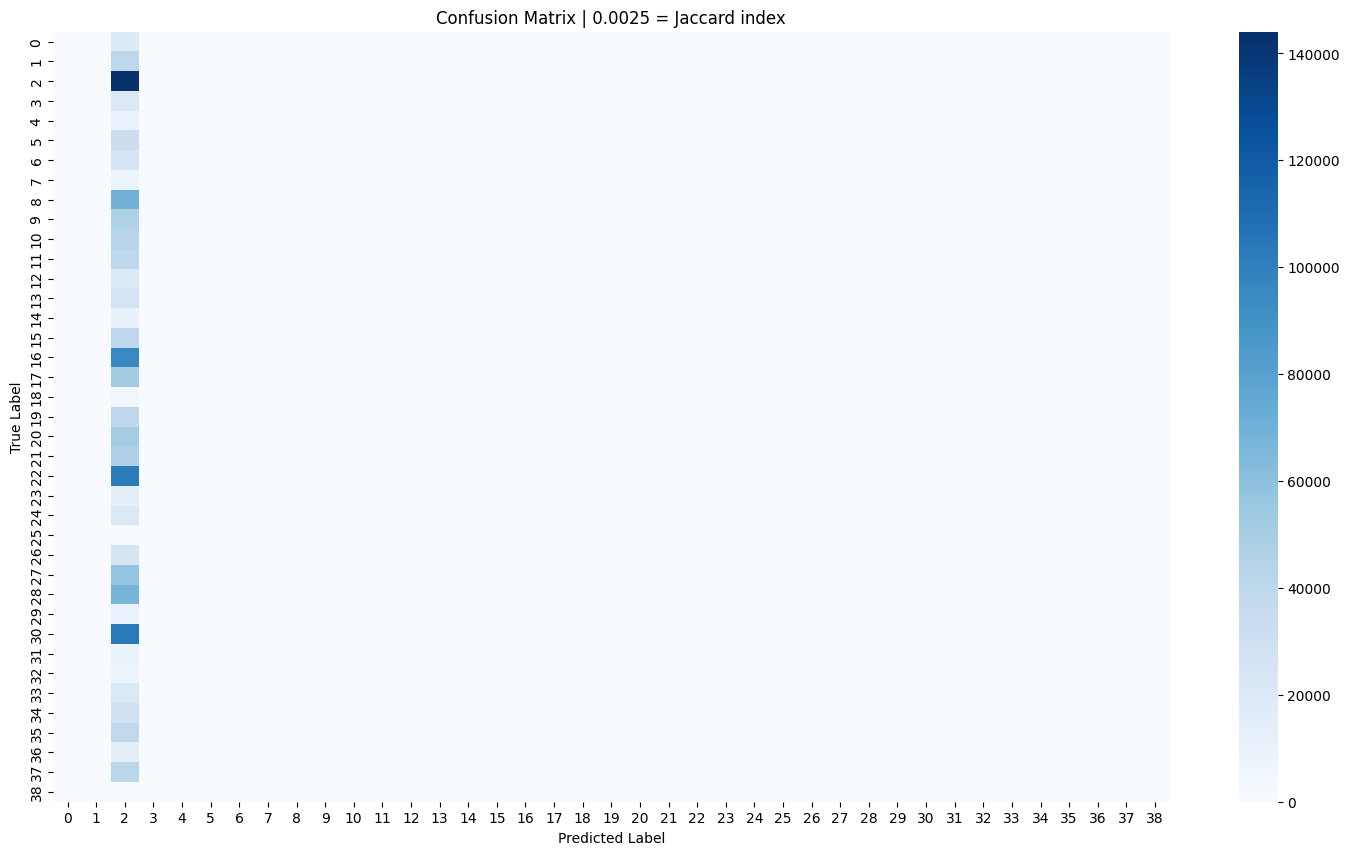

In [ ]:
from sklearn.metrics import confusion_matrix, jaccard_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_preds, labels=np.arange(0,39))
iou = jaccard_score(y_true, y_preds, labels=np.arange(0,39), average="macro")
bal_acc = balanced_accuracy_score(y_true, y_preds)
print(iou)
print(bal_acc)

plt.figure(figsize=(18, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix | {np.round(iou,4)} = Jaccard index')
plt.show()